# ARIMA Forecasting Initial Exploration
### Aim
I want to use the FTSE 100 and FTSE 250 stock price data to try an ARIMA model following the datacamp tutorial [here](https://www.datacamp.com/tutorial/arima).
The decision tree model I tried in the initial data exploration notebook performed poorly. I want to try ARIMA here to see if it performs better.

In [5]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_squared_error

In [2]:
ftse100_path = '../data/raw//ftse_100_historic_prices.csv'
ftse250_path = '../data/raw/ftse_250_historic_prices.csv'
ftse100 = pd.read_csv(ftse100_path)
ftse250 = pd.read_csv(ftse250_path)

ftse100['Date'] = pd.to_datetime(ftse100['Date'])
ftse250['Date'] = pd.to_datetime(ftse250['Date'])
for data in [ftse100, ftse250]:
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["DOM"] = data["Date"].dt.day
    data["Day"] = data["Date"].dt.dayofweek
    data["Week"] = data["Date"].dt.isocalendar().week
    data['DOY'] = data['Date'].dt.dayofyear

In [3]:
ftse100Cons = ftse100['Company'].unique()
ftse250Cons = ftse250['Company'].unique()

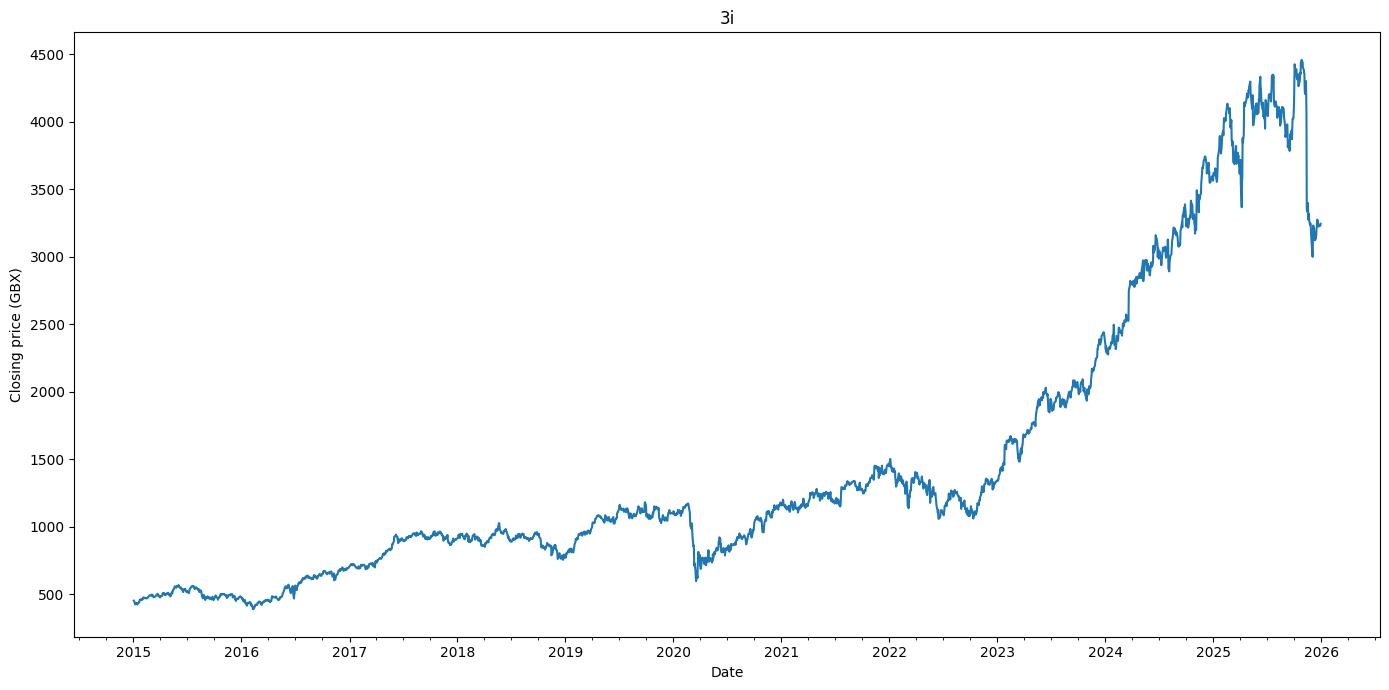

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

subset = ftse100.loc[ftse100['Company'] == "3i"]
ax.plot(subset['Date'], subset['Close'], label="3i")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (GBX)")
ax.set_title("3i")
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator((1,4,7,10)))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))


plt.tight_layout()
plt.show()

According to the tutorial, ARIMA requires data to generally be non-stationary and they cannot deal with time-varying variance. As with all stocks, there is a high degree of time based variability. Will use the tutorials recommended Augmented Dickey-Fuller test to check whether the time series is stationary or not (strongly suspect not).

In [7]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(subset["Close"])
print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")
if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")
# Apply first-order differencing
subset['Close_Diff'] = subset['Close'].diff()
# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(subset["Close_Diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:    
    print("Interpretation: The differenced series is Stationary.")
else:    
    print("Interpretation: The differenced series is Non-Stationary.")

ADF Statistic (Original): -0.2603
p-value (Original): 0.9309
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -13.7891
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


Side note, I want to find some way of doing a long-term identification of differences not just day to day, but look more widely across the time series data to find th e largest relative change in stock price and see if that is a change that can be explained by seasonal variation. The aim of this is to find a regular increase in stock price that can be capitalised on to get a low effort decent return.

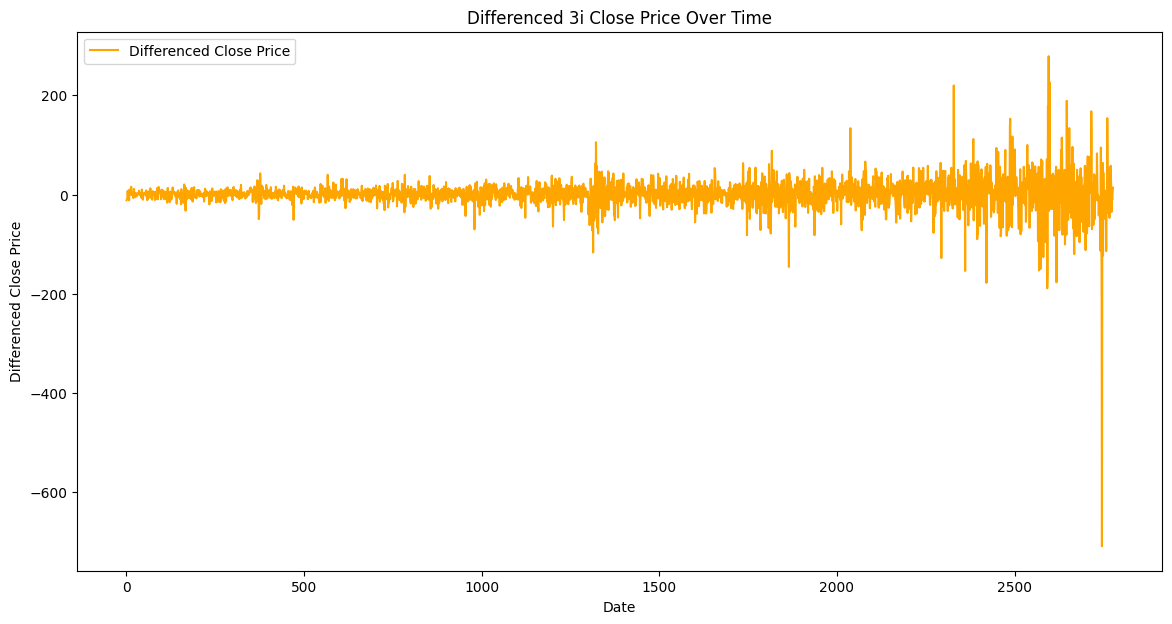

In [10]:
# Plotting the differenced Close price
plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close_Diff'], label='Differenced Close Price', color='orange')
plt.title('Differenced 3i Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()